In [20]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras import layers, Model
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
DATA_DIR = "../watch/src/gesture_data_filtered"

WINDOW_SIZE = 192
STRIDE = 16
CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]

GESTURE_CODES = [
    "D",
    "De",
    "Dn",
    "Ds",
    "DUD",
    "Dw",
    "N",
    "U",
    "Ue",
    "Un",
    "Uw",
]

label_map = {code: i for i, code in enumerate(GESTURE_CODES)}
reverse_label_map = {i: code for code, i in label_map.items()}

In [ ]:
def get_gesture_code(path):
    filename = os.path.basename(path)
    return filename.split("_")[0]


def make_windows(data, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []

    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        windows.append(data[start:end])

    return windows


def load_dataset():
    X = []
    y = []
    used_files = []
    skipped_short = 0

    files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

    print("CSV files found:", len(files))

    for path in files:
        gesture_code = get_gesture_code(path)

        if gesture_code not in label_map:
            continue

        df = pd.read_csv(path)

        if not all(ch in df.columns for ch in CHANNELS):
            print(f"Skipping {path}: missing IMU columns")
            continue

        data = df[CHANNELS].values.astype(np.float32)

        if len(data) < WINDOW_SIZE:
            skipped_short += 1
            continue

        windows = make_windows(data)

        for window in windows:
            X.append(window)
            y.append(label_map[gesture_code])
            used_files.append(path)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print("Skipped short files:", skipped_short)

    return X, y, used_files

X shape: (1127, 64, 6)
y shape: (1127,)
Number of files used: 1127
Label map: {'D': 0, 'De': 1, 'Dn': 2, 'Ds': 3, 'DUD': 4, 'Dw': 5, 'N': 6, 'U': 7, 'Ue': 8, 'Un': 9, 'Uw': 10}


In [10]:
# Checking to make sure all csv files got imported
import os
import glob

DATA_DIR = "../watch/src/gesture_data_filtered"

files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print(DATA_DIR)
print("Number of csv files:", len(files))

if len(files) > 0:
    print(files[:5])

../watch/src/gesture_data_filtered
Number of csv files: 1127
['../watch/src/gesture_data_filtered\\De_no_tremor_1.csv', '../watch/src/gesture_data_filtered\\De_no_tremor_10.csv', '../watch/src/gesture_data_filtered\\De_no_tremor_11.csv', '../watch/src/gesture_data_filtered\\De_no_tremor_12.csv', '../watch/src/gesture_data_filtered\\De_no_tremor_13.csv']


In [ ]:
X, y, used_files = load_dataset()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Windows created:", len(X))
print("Files used:", len(set(used_files)))



for gesture, idx in label_map.items():
    print(gesture, np.sum(y == idx))

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


# Normalize data
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 6))
X_train = scaler.transform(X_train.reshape(-1, 6)).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, 6)).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)

In [12]:
def build_model(num_classes):
    inputs = tf.keras.Input(shape=(WINDOW_SIZE, 6))

    x = layers.Conv1D(64, 5, padding="causal", activation="relu")(inputs)
    x = layers.Conv1D(128, 5, padding="causal", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="causal", activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GRU(128, return_sequences=False)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)


model = build_model(num_classes=len(GESTURE_CODES))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 64, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,395 (782.79 KB)

 Trainable params: 200,395 (782.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16
)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4048 - loss: 1.6708 - val_accuracy: 0.7278 - val_loss: 0.8417
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7728 - loss: 0.7052 - val_accuracy: 0.9053 - val_loss: 0.3686
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9048 - loss: 0.3251 - val_accuracy: 0.9763 - val_loss: 0.1330
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9632 - loss: 0.1564 - val_accuracy: 0.9763 - val_loss: 0.1286
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9746 - loss: 0.1108 - val_accuracy: 0.9822 - val_loss: 0.1034
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9873 - loss: 0.0606 - val_accuracy: 0.9822 - val_loss: 0.0993
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9873 - loss: 0.0700 - val_accuracy: 0.9645 - val_loss: 0.1552
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9873 - loss: 0.0632 - val_accuracy: 0.9763 - v

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9941 - loss: 0.0883    
Test loss: 0.08831151574850082
Test accuracy: 0.9941176176071167
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step
              precision    recall  f1-score   support

           D       1.00      1.00      1.00        13
          De       1.00      1.00      1.00        15
          Dn       1.00      1.00      1.00        15
          Ds       1.00      1.00      1.00        15
         DUD       1.00      1.00      1.00        15
          Dw       1.00      0.94      0.97        16
           N       0.94      1.00      0.97        15
           U       1.00      1.00      1.00        16
          Ue       1.00      1.00      1.00        17
          Un       1.00      1.00      1.00        17
          Uw       1.00      1.00      1.00        16

    accuracy                           0.99       170
   macro avg       0.99      0.99      0.99       170
weighted avg       0.99      0.99      0.99       170

[[13  0

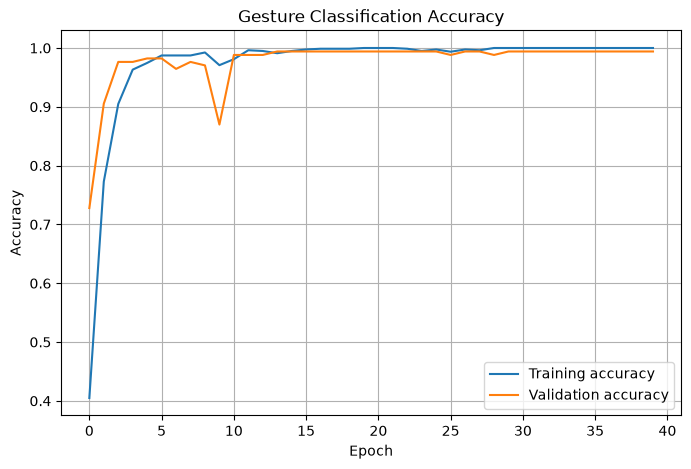

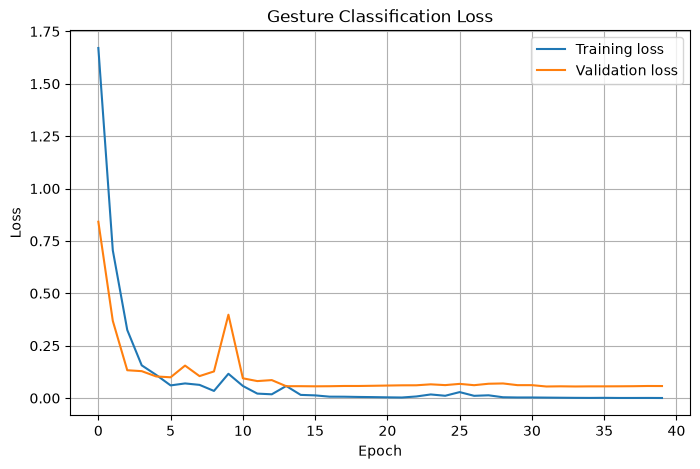

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=GESTURE_CODES))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Gesture Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gesture Classification Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.save("gesture_cnn_gru_sliding_192.keras")
joblib.dump(scaler, "gesture_scaler_sliding_192.pkl")
print("Saved model as gesture_cnn_gru_resampled.keras")

Saved model as gesture_cnn_gru_resampled.keras


In [ ]:
# Check to make sure an even amount of data per class
for gesture, idx in label_map.items():
    print(gesture, np.sum(y == idx))

D 90
De 100
Dn 101
Ds 100
DUD 102
Dw 102
N 100
U 108
Ue 113
Un 109
Uw 102


In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)

print(classification_report(y_test, y_pred, target_names=GESTURE_CODES))
print(confusion_matrix(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9941 - loss: 0.0883    
0.9941176176071167
              precision    recall  f1-score   support

           D       1.00      1.00      1.00        13
          De       1.00      1.00      1.00        15
          Dn       1.00      1.00      1.00        15
          Ds       1.00      1.00      1.00        15
         DUD       1.00      1.00      1.00        15
          Dw       1.00      0.94      0.97        16
           N       0.94      1.00      0.97        15
           U       1.00      1.00      1.00        16
          Ue       1.00      1.00      1.00        17
          Un       1.00      1.00      1.00        17
          Uw       1.00      1.00      1.00        16

    accuracy                           0.99       170
   macro avg       0.99      0.99      0.99       170
weighted avg       0.99      0.99      0.99       170

[[13  0  0  0  0  0  0  0  0  0  0]
 [ 0 15  0  0  0  0  0  0  0  0  0]
 [ 0  0 15  0  0  0 

In [19]:
import os
import glob
import pandas as pd
import numpy as np

files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

lengths = []

for f in files:
    df = pd.read_csv(f)
    lengths.append(len(df))

print("Minimum:", np.min(lengths))
print("Average:", np.mean(lengths))
print("Maximum:", np.max(lengths))

Minimum: 17
Average: 229.93700088731146
Maximum: 646
